# GraphRAG: Graph-Enhanced Retrieval-Augmented Generation

This notebook implements a practical GraphRAG pipeline:

**Documents → chunks → embeddings → concept extraction → knowledge graph → vector retrieval → graph traversal → LLM answer**

The graph connects chunks using semantic similarity and shared concepts. During retrieval, the most relevant chunks are used as starting nodes and the graph is traversed to collect additional connected context.

## 1. Install dependencies

Run this cell once in a fresh environment.

```bash
!pip install -q langchain langchain-community langchain-huggingface langchain-groq 
sentence-transformers scikit-learn networkx spacy numpy
```

## 2. Imports and configuration

In [1]:
import os
import re
import heapq
import numpy as np
import networkx as nx

from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

C:\Users\sk335\AppData\Local\Temp\ipykernel_20240\646012508.py:14: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, TextLoader
c:\Users\sk335\OneDrive\Documents\Coding\PythonProjects\rag_techniques\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Environment variables

Set your Groq API key before running the LLM cells.

In [2]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
HUGGINGFACE_API_KEY = os.getenv("HUGGINGFACE_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is not set")

if not HUGGINGFACE_API_KEY:
    raise ValueError("HUGGINGFACE_API_KEY is not set")

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
LLM_MODEL = "openai/gpt-oss-20b"

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

llm = ChatGroq(
    model=LLM_MODEL,
    temperature=0.1,
    max_tokens=2048,
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9697.49it/s]


## 4. Load documents

You can use PDF or TXT files. Put your files inside the `data/` directory.

In [3]:
DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

def load_documents(data_dir: Path):
    documents = []

    for path in data_dir.glob("**/*"):
        if path.suffix.lower() == ".pdf":
            documents.extend(PyPDFLoader(str(path)).load())
        elif path.suffix.lower() == ".txt":
            documents.extend(TextLoader(str(path), encoding="utf-8").load())

    return documents

raw_documents = load_documents(DATA_DIR)
print(f"Loaded documents: {len(raw_documents)}")

Loaded documents: 90


## 5. Example documents

If the `data/` folder is empty, this small dataset lets you test the notebook immediately.

In [4]:
if not raw_documents:
    raw_documents = [
        Document(page_content=(
            "LangGraph is a framework for building stateful, multi-step AI agent workflows. "
            "It represents workflows as graphs containing nodes and edges."
        ), metadata={"source": "example-1"}),
        Document(page_content=(
            "RAG combines retrieval with language generation. A retriever finds relevant documents "
            "and the language model uses the retrieved context to generate an answer."
        ), metadata={"source": "example-2"}),
        Document(page_content=(
            "GraphRAG enhances RAG by connecting related chunks in a knowledge graph. "
            "Graph traversal can retrieve information that is distributed across multiple chunks."
        ), metadata={"source": "example-3"}),
        Document(page_content=(
            "Vector embeddings represent text as numerical vectors. Cosine similarity can be used "
            "to compare embeddings and find semantically similar chunks."
        ), metadata={"source": "example-4"}),
    ]

print(f"Documents available: {len(raw_documents)}")

Documents available: 90


## 6. Split documents into chunks

In [5]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=80,
)

chunks = splitter.split_documents(raw_documents)

for i, chunk in enumerate(chunks):
    chunk.metadata["chunk_id"] = i

print(f"Created {len(chunks)} chunks")
print(chunks[0].page_content)

Created 565 chunks
A I E N G I N E E R I N G I N S I D E R S E R I E S
PRODUCTION-GRADE PYTHON · FASTAPI
FastAPI
for AI Engineers
From First Endpoint to Production-Scale AI Systems
Covering REST design, Pydantic validation, async patterns,
databases, security, LLM & RAG serving, and system design —
with 100 interview questions.
aiengineeringinsider.com · aiengineeringinsider.substack.com/subscribe AI ENGINEERING INSIDER


## 7. Create embeddings

Each chunk receives a vector representation. These vectors are used for initial query retrieval and graph edge construction.

In [6]:
texts = [doc.page_content for doc in chunks]
chunk_embeddings = np.array(embeddings.embed_documents(texts))

print("Embedding matrix shape:", chunk_embeddings.shape)

Embedding matrix shape: (565, 384)


## 8. Extract concepts

This lightweight extractor creates normalized concepts from the text. For production systems, you can replace it with an LLM-based entity/relation extractor.

In [7]:
STOPWORDS = {
    "the", "and", "for", "with", "that", "this", "from", "are", "was",
    "can", "into", "using", "used", "each", "has", "have", "its", "their",
    "they", "will", "than", "then", "also", "not", "but", "you", "your"
}

def normalize_word(word):
    word = word.lower().strip()
    word = re.sub(r"[^a-z0-9-]", "", word)
    return word

def extract_concepts(text, max_concepts=25):
    words = [normalize_word(w) for w in re.findall(r"[A-Za-z][A-Za-z0-9-]+", text)]
    concepts = []

    for word in words:
        if len(word) >= 4 and word not in STOPWORDS and word not in concepts:
            concepts.append(word)

    return set(concepts[:max_concepts])

concepts_by_node = {
    i: extract_concepts(doc.page_content)
    for i, doc in enumerate(chunks)
}

for node, concepts in concepts_by_node.items():
    print(node, sorted(concepts))

0 ['aiengineeringinsider', 'async', 'covering', 'databases', 'design', 'endpoint', 'engineering', 'engineers', 'fastapi', 'first', 'interview', 'patterns', 'production-grade', 'production-scale', 'pydantic', 'python', 'questions', 'rest', 'security', 'serving', 'subscribe', 'substack', 'system', 'systems', 'validation']
1 ['aiengineeringinsider', 'brief', 'copyright', 'endpoint', 'engineering', 'engineers', 'except', 'fastapi', 'first', 'form', 'insider', 'part', 'permission', 'prior', 'production-scale', 'publication', 'reproduced', 'reserved', 'rights', 'subscribe', 'substack', 'systems', 'transmitted', 'without', 'written']
2 ['assumes', 'contained', 'damages', 'edition', 'errors', 'first', 'herein', 'information', 'omissions', 'owners', 'property', 'publisher', 'respective', 'responsibility', 'resulting', 'trademarks']
3 ['contents', 'development', 'django', 'fastapi', 'flask', 'fundamentals', 'introduction', 'modern', 'rest', 'what']
4 ['asgi', 'dominates', 'endpoint', 'fastapi', 

## 9. Build the knowledge graph

Nodes represent chunks. Edges are created when chunks are semantically similar or share concepts.

The edge weight is converted into a graph cost so that a Dijkstra-style traversal prefers stronger relationships.

In [8]:
graph = nx.Graph()

for i, doc in enumerate(chunks):
    graph.add_node(
        i,
        text=doc.page_content,
        source=doc.metadata.get("source", "unknown"),
        concepts=concepts_by_node[i],
    )

similarity_matrix = cosine_similarity(chunk_embeddings)
SEMANTIC_THRESHOLD = 0.35

for i in range(len(chunks)):
    for j in range(i + 1, len(chunks)):
        semantic_score = float(similarity_matrix[i, j])
        shared = concepts_by_node[i] & concepts_by_node[j]
        concept_score = min(len(shared) / 5.0, 1.0)

        relationship_strength = 0.7 * semantic_score + 0.3 * concept_score

        if semantic_score >= SEMANTIC_THRESHOLD or shared:
            graph.add_edge(
                i,
                j,
                strength=relationship_strength,
                cost=1.0 / (relationship_strength + 1e-6),
                shared_concepts=sorted(shared),
            )

print("Nodes:", graph.number_of_nodes())
print("Edges:", graph.number_of_edges())

Nodes: 565
Edges: 63548


## 10. Visualize the knowledge graph

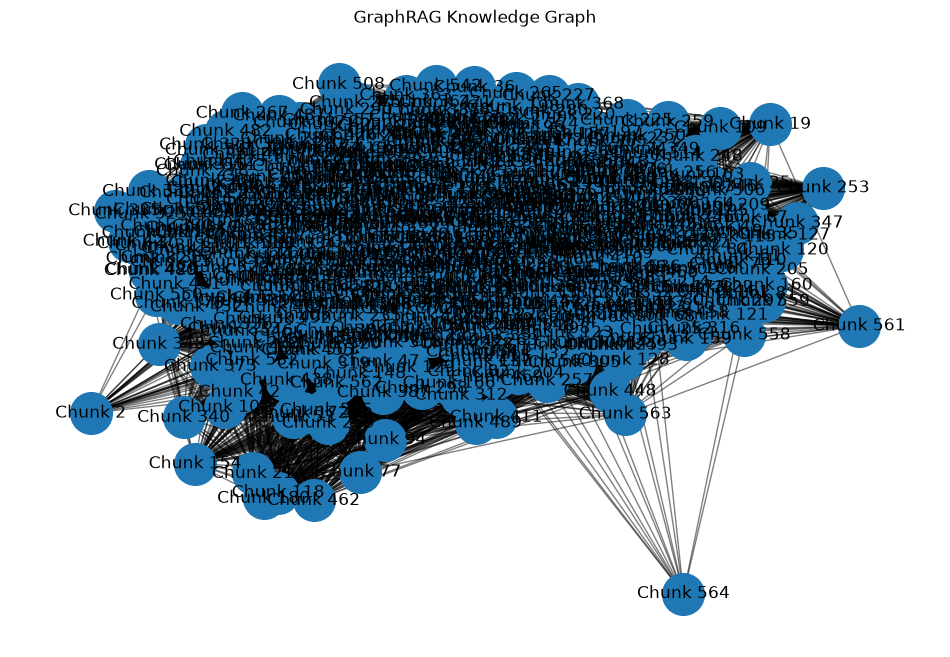

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(graph, seed=42)

nx.draw_networkx_nodes(graph, pos, node_size=900)
nx.draw_networkx_edges(graph, pos, alpha=0.5)
nx.draw_networkx_labels(graph, pos, labels={i: f"Chunk {i}" for i in graph.nodes})

plt.title("GraphRAG Knowledge Graph")
plt.axis("off")
plt.show()

## 11. Initial vector retrieval

In [10]:
def vector_search(query, top_k=3):
    query_vector = np.array(embeddings.embed_query(query)).reshape(1, -1)
    scores = cosine_similarity(query_vector, chunk_embeddings)[0]
    indices = np.argsort(scores)[::-1][:top_k]

    return [(int(i), float(scores[i])) for i in indices]

query = "How does GraphRAG improve retrieval across related information?"
initial_results = vector_search(query, top_k=3)

for node, score in initial_results:
    print(f"Chunk {node} | score={score:.4f}")
    print(chunks[node].page_content)
    print()

Chunk 179 | score=0.4076
binations). (2) Cursor pagination keyed on (sort_field, id) for stability; expose next_cursor
opaque token, never raw offsets. (3) Cap limit at 50; mobile clients page incrementally. (4)
ETag headers on detail endpoints so clients revalidate cheaply . (5) Read replicas or a search en-
gine (OpenSearch) once facet combinations exceed what B-tree indexes serve; the API contract
stays identical — only the repository implementation changes (Chapter 4’s layering pays off

Chunk 487 | score=0.3938
(WHERE team_id = ... in the same query — huge for access control), and HNSW indexes that
comfortably serve up to millions of vectors at tens of ms. Dedicated engines (Qdrant, Weaviate,
Pinecone, Milvus): better horizontal scale-out, faster ANN at the 10M–1B range, richer built-in
hybrid (sparse+dense) search and quantization options — at the price of a second datastore:
dual writes, consistency between metadata and vectors, separate ops/backup/auth. Migration

Chunk 227 | s

## 12. Graph traversal

The traversal starts from vector-retrieved nodes. A priority queue explores connected nodes while limiting the number of chunks added to the final context.

This is intentionally a practical approximation of a Dijkstra-like GraphRAG traversal rather than a strict shortest-path implementation.

In [11]:
def graph_retrieve(query, top_k=3, max_chunks=8, max_hops=3):
    query_vector = np.array(embeddings.embed_query(query)).reshape(1, -1)
    query_scores = cosine_similarity(query_vector, chunk_embeddings)[0]

    seeds = np.argsort(query_scores)[::-1][:top_k]

    # Priority queue entries: (-priority, node, hops)
    queue = []
    best_priority = {}
    parent = {}
    visited = set()

    for node in seeds:
        priority = float(query_scores[node])
        best_priority[int(node)] = priority
        heapq.heappush(queue, (-priority, int(node), 0))

    selected = []

    while queue and len(selected) < max_chunks:
        neg_priority, node, hops = heapq.heappop(queue)
        priority = -neg_priority

        if node in visited:
            continue

        visited.add(node)
        selected.append({
            "node": node,
            "score": priority,
            "hops": hops,
            "parent": parent.get(node),
        })

        if hops >= max_hops:
            continue

        for neighbor in graph.neighbors(node):
            if neighbor in visited:
                continue

            edge_strength = graph[node][neighbor]["strength"]
            neighbor_query_score = float(query_scores[neighbor])

            # Blend direct query relevance and graph relationship strength.
            new_priority = 0.6 * neighbor_query_score + 0.4 * edge_strength

            if new_priority > best_priority.get(neighbor, -np.inf):
                best_priority[neighbor] = new_priority
                parent[neighbor] = node
                heapq.heappush(queue, (-new_priority, neighbor, hops + 1))

    return selected

retrieved = graph_retrieve(query)

for item in retrieved:
    node = item["node"]
    print(
        f"Chunk {node} | priority={item['score']:.4f} | hops={item['hops']} | "
        f"parent={item['parent']}"
    )

Chunk 179 | priority=0.4076 | hops=0 | parent=None
Chunk 487 | priority=0.3938 | hops=0 | parent=None
Chunk 171 | priority=0.3807 | hops=1 | parent=179
Chunk 184 | priority=0.3847 | hops=2 | parent=171
Chunk 183 | priority=0.4024 | hops=3 | parent=184
Chunk 177 | priority=0.3791 | hops=1 | parent=179
Chunk 176 | priority=0.4071 | hops=2 | parent=177
Chunk 198 | priority=0.3853 | hops=3 | parent=176


## 13. Build the final context

Only the selected chunks are sent to the language model. This helps control the context window instead of sending the entire knowledge base.

In [12]:
def build_context(retrieved_items):
    parts = []

    for item in retrieved_items:
        node = item["node"]
        parts.append(
            f"[Chunk {node}]\n{chunks[node].page_content}"
        )

    return "\n\n".join(parts)

context = build_context(retrieved)
print(context)

[Chunk 179]
binations). (2) Cursor pagination keyed on (sort_field, id) for stability; expose next_cursor
opaque token, never raw offsets. (3) Cap limit at 50; mobile clients page incrementally. (4)
ETag headers on detail endpoints so clients revalidate cheaply . (5) Read replicas or a search en-
gine (OpenSearch) once facet combinations exceed what B-tree indexes serve; the API contract
stays identical — only the repository implementation changes (Chapter 4’s layering pays off

[Chunk 487]
(WHERE team_id = ... in the same query — huge for access control), and HNSW indexes that
comfortably serve up to millions of vectors at tens of ms. Dedicated engines (Qdrant, Weaviate,
Pinecone, Milvus): better horizontal scale-out, faster ANN at the 10M–1B range, richer built-in
hybrid (sparse+dense) search and quantization options — at the price of a second datastore:
dual writes, consistency between metadata and vectors, separate ops/backup/auth. Migration

[Chunk 171]
?after=2024-06-01,9182) and

## 14. Generate the answer with Groq

In [13]:
prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a helpful GraphRAG assistant. Answer only from the provided context. "
        "If the context does not contain enough information, say so."
    ),
    (
        "human",
        "Context:\n{context}\n\nQuestion:\n{question}\n\n"
        "Give a concise, accurate answer and mention the relevant chunks when useful."
    ),
])

chain = prompt | llm

response = chain.invoke({
    "context": context,
    "question": query,
})

print(response.content)

I’m sorry, but the provided context does not contain any information about GraphRAG or how it improves retrieval across related information.


## 15. Visualize the traversal path

The selected nodes and parent relationships show how the graph was traversed for the query.

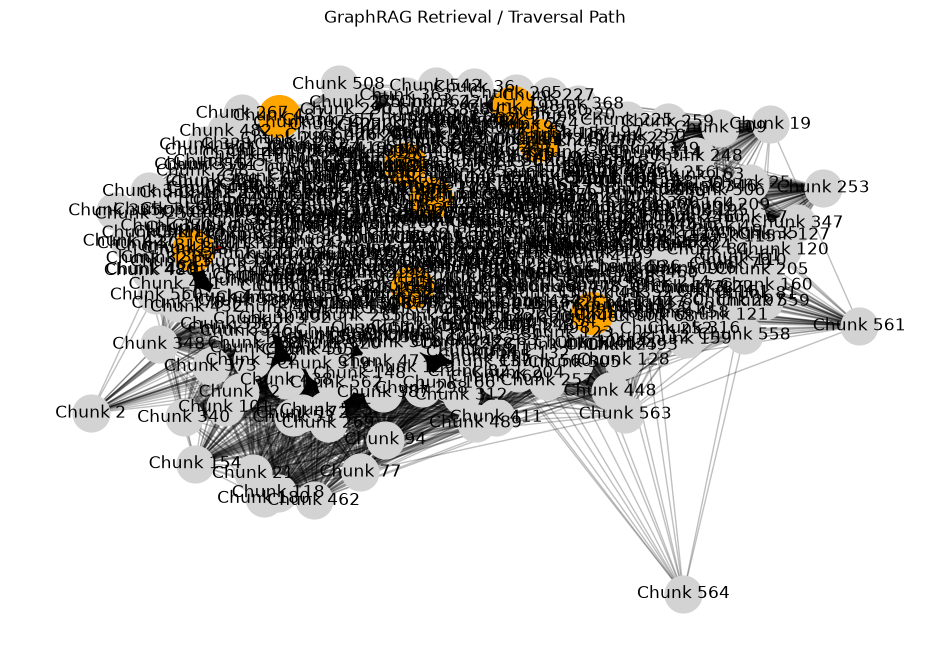

In [14]:
def visualize_traversal(graph, retrieved_items):
    selected_nodes = [item["node"] for item in retrieved_items]
    path_edges = []

    for item in retrieved_items:
        if item["parent"] is not None:
            path_edges.append((item["parent"], item["node"]))

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(graph, seed=42)

    nx.draw_networkx_nodes(graph, pos, node_size=700, node_color="lightgray")
    nx.draw_networkx_edges(graph, pos, alpha=0.25)

    nx.draw_networkx_nodes(
        graph,
        pos,
        nodelist=selected_nodes,
        node_size=900,
        node_color="orange",
    )

    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=path_edges,
        width=3,
        edge_color="red",
        style="dashed",
        arrows=True,
        connectionstyle="arc3,rad=0.15",
    )

    nx.draw_networkx_labels(
        graph,
        pos,
        labels={i: f"Chunk {i}" for i in graph.nodes},
    )

    plt.title("GraphRAG Retrieval / Traversal Path")
    plt.axis("off")
    plt.show()

visualize_traversal(graph, retrieved)

## 16. Complete query function

This function combines retrieval, graph traversal, context construction, and generation into one call.

In [15]:
def ask_graphrag(question, top_k=3, max_chunks=8, max_hops=3):
    retrieved = graph_retrieve(
        question,
        top_k=top_k,
        max_chunks=max_chunks,
        max_hops=max_hops,
    )

    context = build_context(retrieved)

    result = chain.invoke({
        "context": context,
        "question": question,
    })

    return {
        "answer": result.content,
        "retrieved_nodes": retrieved,
        "context": context,
    }

result = ask_graphrag(
    "What is GraphRAG and why can graph traversal improve RAG?"
)

print(result["answer"])
print("\nRetrieved nodes:", [x["node"] for x in result["retrieved_nodes"]])

I’m sorry, but the provided context does not contain any information about “GraphRAG” or how graph traversal might improve Retrieval‑Augmented Generation.

Retrieved nodes: [481, 56, 544, 541, 49, 459, 486, 26]


## 17. Architecture

```text
                 ┌─────────────────┐
                 │     Documents   │
                 └────────┬────────┘
                          │
                    Chunk + Embed
                          │
              ┌───────────┴───────────┐
              │                       │
        Vector Index             Knowledge Graph
              │                       │
              └───────────┬───────────┘
                          │
                       Query
                          │
                 Initial Retrieval
                          │
                   Graph Traversal
                          │
                  Selected Context
                          │
                         LLM
                          │
                        Answer
```

## 18. Notes for production

- Replace the simple concept extractor with LLM-based entity and relationship extraction.
- For large datasets, use a persistent vector database instead of keeping embeddings in memory.
- Consider Neo4j, Memgraph, or another graph database for a production knowledge graph.
- Add metadata filtering for users, documents, groups, permissions, and timestamps.
- Use a token budget when building the final context so multi-hop retrieval cannot overflow the model context window.
- Add reranking after graph traversal to improve the quality of the final context.
- Cache embeddings and extracted graph information so documents do not need to be processed repeatedly.
- For very large graphs, use bounded traversal depth and a maximum number of retrieved chunks.